In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra, StatsBase;

┌ Info: Precompiling JJDFTX [0d21db8c-e7cb-497b-98f4-4306b49e2569]
└ @ Base loading.jl:1317


Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
lattice_vectors = loadlattice("wannier.out")
Moire7_lattice = loadlattice("wannier.out")

3-element Vector{Vector{Float64}}:
 [-6.2541842099, 2.1665141392400002, 0.0]
 [1.25083684198, -6.499563584800001, 0.0]
 [0.0, 0.0, 21.16708]

In [4]:
export_hwannier("wannier", spin=Val('d'))
export_momentum("wannier", spin=Val('d'))
export_heph("wannier", spin=Val('d'));

In [4]:
Hwannier, cell_map = hwannier("wannierDn"), np.loadtxt("wannierDn.map.txt")
Pwannier = pwannier("wannierDn")
Heph, celleph_map = hephwannier("wannierDn"), np.loadtxt("wannierDn.mapeph.txt");
force_matrix, cellph_map = phonon_force_matrix("totalE");

In [12]:
Hwannierup, cell_mapup = hwannier("wannierUp"), np.loadtxt("wannierUp.map.txt");
Hwannierdn, cell_mapdn = hwannier("wannierDn"), np.loadtxt("wannierDn.map.txt");
phonon_bands = phonon_dispersion(force_matrix, cellph_map, return_negative=true);

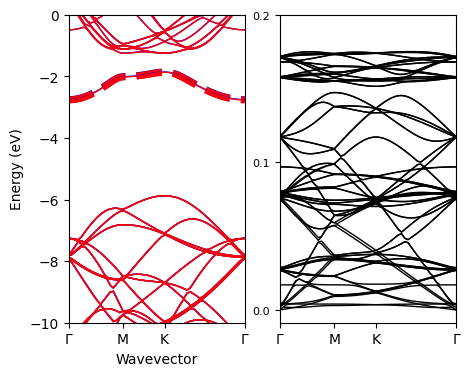

(PyObject[PyObject <matplotlib.axis.YTick object at 0x7efbc2a16760>, PyObject <matplotlib.axis.YTick object at 0x7efbc2a16340>, PyObject <matplotlib.axis.YTick object at 0x7efbc2a12190>], PyObject[PyObject Text(0, 0.0, '0.0'), PyObject Text(0, 0.1, '0.1'), PyObject Text(0, 0.2, '0.2')])

In [14]:
figure(figsize=(5, 4))
subplot(1, 2, 1)
plot_bands(Hwannierup, cell_mapup, linewidth=5, color="blue", linestyle="dashed")
plot_bands(Hwannierdn, cell_mapdn, linewidth=5, color="red", linestyle="dashed")
plot_bands("../Na-bands.eigenvals", spin=2, linewidth=1)
ylim(-10, 0)
subplot(1, 2, 2)
plot(phonon_bands, linewidth=1, color="black")
label_plots()
yticks([0, 0.1, 0.2], fontsize=8)
#ylim(-0.01, 0.01)

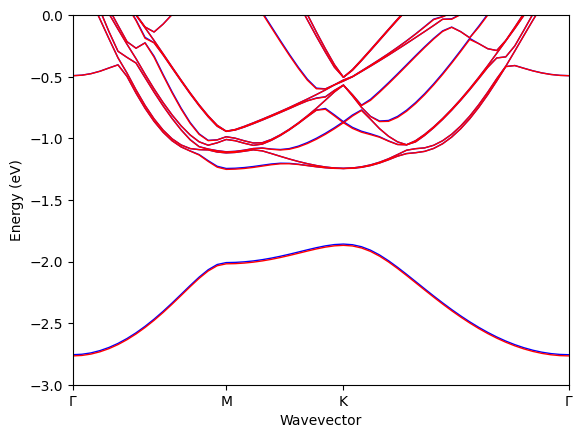

(-3.0, 0.0)

In [38]:
plot_bands("../Na-bands.eigenvals", spin=2, linewidth=1)
ylim(-3, 0)

In [97]:
bandprops = JJDFTX.bandstruct_properties("../Na-bands.eigenvals", spin=2)[1][8*7+6]

(-1.24472617929372, -0.4033368312226189)

In [64]:
kpoints = bandstructkpoints2q()
impolarizations = []
for kpt in kpoints
    println(kpt)
    push!(impolarizations, real(ImΠ(Hwannier, cell_map, lattice_vectors, kpt, -2.4, monte_carlo=true, mesh=30, num_blocks=200, normalized=true, degeneracy=2)))
end

[0.0, 0.0, 0.0]
[0.0, 0.0, 0.0]
[0.029411764706, 0.0, 0.0]
[0.029411764706, 0.0, 0.0]
[0.058823529412, 0.0, 0.0]
[0.058823529412, 0.0, 0.0]
[0.088235294118, 0.0, 0.0]
[0.088235294118, 0.0, 0.0]
[0.117647058824, 0.0, 0.0]
[0.117647058824, 0.0, 0.0]
[0.147058823529, 0.0, 0.0]
[0.147058823529, 0.0, 0.0]
[0.176470588235, 0.0, 0.0]
[0.176470588235, 0.0, 0.0]
[0.205882352941, 0.0, 0.0]
[0.205882352941, 0.0, 0.0]
[0.235294117647, 0.0, 0.0]
[0.235294117647, 0.0, 0.0]
[0.264705882353, 0.0, 0.0]
[0.264705882353, 0.0, 0.0]
[0.294117647059, 0.0, 0.0]
[0.294117647059, 0.0, 0.0]
[0.323529411765, 0.0, 0.0]
[0.323529411765, 0.0, 0.0]
[0.352941176471, 0.0, 0.0]
[0.352941176471, 0.0, 0.0]
[0.382352941176, 0.0, 0.0]
[0.382352941176, 0.0, 0.0]
[0.411764705882, 0.0, 0.0]
[0.411764705882, 0.0, 0.0]
[0.441176470588, 0.0, 0.0]
[0.441176470588, 0.0, 0.0]
[0.470588235294, 0.0, 0.0]
[0.470588235294, 0.0, 0.0]
[0.5, 0.0, 0.0]
[0.5, 0.0, 0.0]
[0.512820512769, -0.025641025385, 0.0]
[0.512820512769, -0.025641025385,

In [79]:
epsilons = zeros(56, 100)
for (i, (impol, kpt)) in enumerate(zip(impolarizations, kpoints))
    for (j, ω) in enumerate(range(0, 3, length=100))
        epsilons[i, j]  = imag(-1 / ϵ(kpt, lattice_vectors, ω, collect(range(0, 100, length=10000)), impol, δ=0.1))
    end
end

In [147]:
using LinearAlgebra

In [148]:
norm([1, 1, 0])

1.4142135623730951

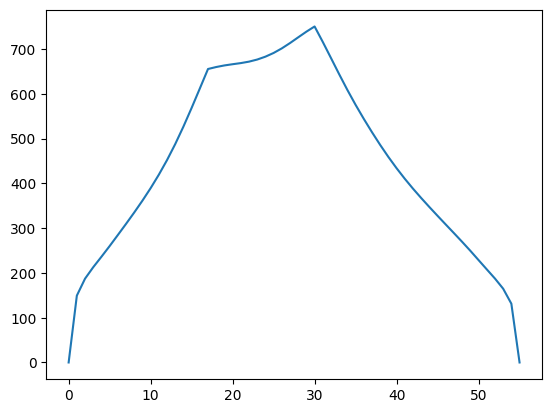

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7efbae02ca90>

In [150]:
plasmon = smooth([range(0, 3, length=100)[argmax(eps)] for eps in eachrow(epsilons)], win_len=10)
plot(c*ħ*norm.(unnormalize_kvector.(Ref(lattice_vectors), bandstructkpoints2q())) ./ plasmon)

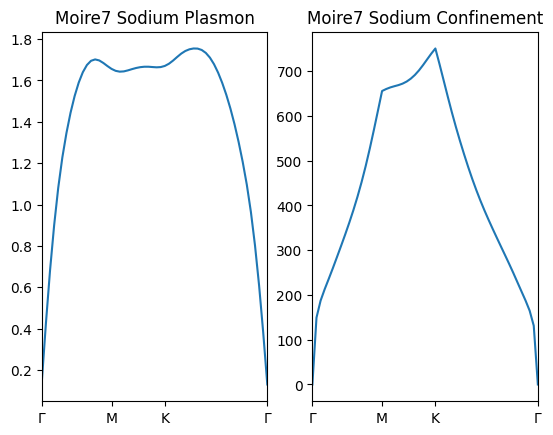

PyObject Text(0.5, 1.0, 'Moire7 Sodium Confinement')

In [153]:
subplot(1, 2, 1)
plot(smooth([range(0, 3, length=100)[argmax(eps)] for eps in eachrow(epsilons)], win_len=10))
label_plots()
title("Moire7 Sodium Plasmon")
subplot(1, 2, 2)
plot(c*ħ*norm.(unnormalize_kvector.(Ref(lattice_vectors), bandstructkpoints2q())) ./ plasmon)
label_plots()
title("Moire7 Sodium Confinement")

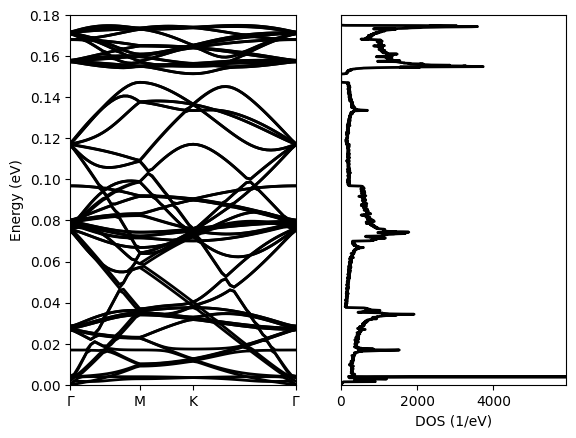

false

In [35]:
bands_overlayed_dos((Eph, Dph), phonon_bands, energy_range=(0, 0.18))

In [6]:
Eup, Dup = density_of_states(Hwannierup, cell_mapup, Val(2), monte_carlo=true, mesh=100, histogram_width=100)
Edn, Ddn = density_of_states(Hwannierdn, cell_mapdn, Val(2), monte_carlo=true, mesh=100, histogram_width=100)

([-3.7661768103054656, -3.756185873058096, -3.746194935810726, -3.736203998563356, -3.726213061315986, -3.7162221240686164, -3.7062311868212463, -3.6962402495738766, -3.6862493123265065, -3.676258375079137  …  -0.9687143810419041, -0.958723443794534, -0.9487325065471643, -0.9387415692997947, -0.9287506320524246, -0.9187596948050549, -0.9087687575576848, -0.8987778203103152, -0.8887868830629451, -0.8787959458155754], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [7]:
dos_properties(Edn, Ddn)

2-element Vector{Float64}:
 -2.777074022815849
 -1.8678987333051917

In [8]:
dos_properties(Eup, Dup)

2-element Vector{Float64}:
 -2.7672732710036634
 -1.8579209473587845

In [30]:
dos_properties(Eph, Dph)

4-element Vector{Float64}:
 -0.00018672397714170064
  0.14731494012609803
  0.1513149852543214
  0.1751152537672509

In [34]:
0.175+0.909

1.084

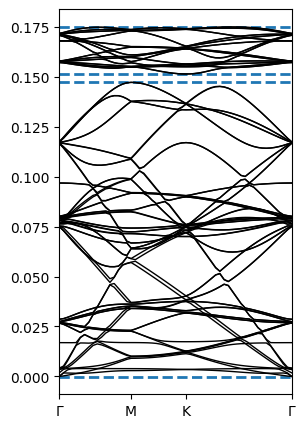

(0.0, 55.0)

In [33]:
figure(figsize=(3, 5))
plot(phonon_bands, linewidth=1, color="black")
hlines(dos_properties(Eph, Dph), 0, 55, linestyle="dashed", linewidth=2)
label_plots()

In [28]:
Eph, Dph = phonon_dos(force_matrix, cellph_map, Val(2), mesh=10, num_blocks=100, monte_carlo=true, histogram_width=10000)

([-0.9999980037765928, -0.9998980026483871, -0.9997980015201816, -0.999698000391976, -0.9995979992637705, -0.9994979981355648, -0.9993979970073592, -0.9992979958791537, -0.9991979947509481, -0.9990979936227424  …  1.1740265234128515, 1.1741265245410573, 1.174226525669263, 1.1743265267974683, 1.174426527925674, 1.1745265290538798, 1.174626530182085, 1.1747265313102908, 1.1748265324384966, 1.1749265335667018], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [26]:
-1.8678916503498897 + 2.777

0.9091083496501104

In [36]:
 -2.217+1.1

-1.117

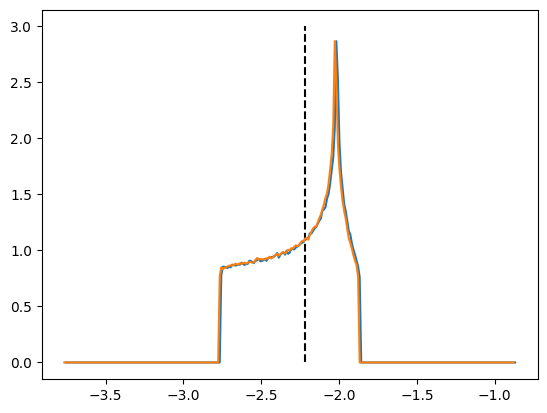

PyObject <matplotlib.collections.LineCollection object at 0x7f7a62547580>

In [82]:
plot(E, D)
plot(Edn, Ddn)

vlines([-2.217655688680553], 0, 3, linestyle="dashed", color="black" )

In [92]:
function Mkk(Heph::Array{<:Real, 3}, celleph_map::Matrix{<:Real}, omegaphs::Array{<:Float64, 4},
    Uphs::Array{<:ComplexF64, 5}, k1s::AbstractArray{<:Real}, k2s::AbstractArray{<:Real})
    
    phase1 = exp.((2im*π)*(np.tensordot(celleph_map, k1s, axes=1)))
    phase2 = exp.((2im*π)*(np.tensordot(celleph_map, k2s, axes=1)))
    normFac = np.sqrt(0.5 ./ np.maximum(omegaphs,1e-6))

    g = np.einsum("kpqxy, kpqx-> kpqy", Uphs, 
    np.einsum("Rkpq, kpqRx -> kpqx", phase2, 
    np.einsum("rkpq, rRx -> kpqRx", conj(phase1), 
    Heph))) .* normFac 

    return g/eV
end
function Mkk(Heph::Array{<:Real, 3}, celleph_map::Matrix{<:Real}, force_matrix::Array{<:Real, 3}, 
    cellph_map::Matrix{<:Real}, k1s::AbstractArray{<:Real}, k2s::AbstractArray{<:Real}, qs::AbstractArray{<:Real})

    phonon_phase = np.exp(2im*π*np.tensordot(cellph_map, qs, axes=1))
    omegaphsquareds, Uphs = np.linalg.eigh(np.einsum("kij, klqr -> lqrij", force_matrix, phonon_phase))
    omegaphs = sqrt.(abs.(omegaphsquareds))
    return Mkk(Heph, celleph_map, omegaphs, Uphs, k1s, k2s), omegaphs, Uphs
end
function ek(Hwannier::Array{Float64, 3}, cell_map::Matrix{Float64}, kpoints::AbstractArray{<:Real}) 
    Es, Us = np.linalg.eigh(np.einsum("kij, klqr -> lqrij", Hwannier, np.exp(2im*np.pi*np.tensordot(cell_map, kpoints, axes=1) )))
    return Es./eV 
end


ek (generic function with 1 method)

In [98]:
N = 10
histogram_width=100
loss = zeros(3*histogram_width)
num_blocks=30
cell_map2d = cell_map[:, 1:2]
celleph_map2d = celleph_map[:, 1:2]
cellph_map2d = cellph_map[:, 1:2]
Heph1band = Heph[:, :, :, 1, 1]
μ = -2.4
for i in 1:num_blocks
    println("Block: $i"); flush(stdout)
    k1 = rand(2, N, 1, 1)
    k2 = rand(2, 1, N, 1)
    k3 = rand(2, 1, 1, N)

    ek1  = ek(Hwannier, cell_map2d, k1)
    ek2 = ek(Hwannier, cell_map2d, k2)
    ek3 = ek(Hwannier, cell_map2d, k3)
    
    ek1 = np.repeat(np.repeat(ek1[:, :, :, 1], N, axis=1), N, axis=2)
    ek2 = np.repeat(np.repeat(ek2[:, :, :, 1], N, axis=0), N, axis=2)
    ek3 = np.repeat(np.repeat(ek3[:, :, :, 1], N, axis=0), N, axis=1)
    
    k1 = np.repeat(np.repeat(k1, N, axis=2), N, axis=3)
    k2 = np.repeat(np.repeat(k2, N, axis=1), N, axis=3)
    k3 = np.repeat(np.repeat(k3, N, axis=1), N, axis=2)

    g1, omega1, Uph1 = Mkk(Heph1band, celleph_map2d, force_matrix, cellph_map2d, k2, k1, k2-k1)
    g2, omega2, Uph2 = Mkk(Heph1band, celleph_map2d, force_matrix, cellph_map2d, k3+k2-k1, k2, k3-k1)
    g3 = Mkk(Heph1band, celleph_map2d, omega2, Uph2, k3, k1)
    g4 = Mkk(Heph1band, celleph_map2d, omega1, Uph1, k3+k2-k1, k3)

    ek4 = ek(Hwannier, cell_map2d, k3+k2-k1)
    ek4 = ek4[:, :, :, 1]
    omega1 .*= 1/eV
    omega2 .*= 1/eV
    
    A1 = np.einsum("kpql, kpqo -> kpqlo", g1 ./ (ek2 - ek1 .+ omega1 .+ 0.1im), g2 ./ (ek4 - ek2 .+ omega2 .+ 0.1im))
    A2 = np.einsum("kpql, kpqo -> kpqlo", g4 ./ (ek4 - ek3 .+ omega1 .+ 0.1im), g3 ./ (ek3 - ek1 .+ omega2 .+ 0.1im))

    weights = np.einsum("kpq, kpqlo->kpqlo", np.heaviside(μ .- ek1, 0.5) .* np.heaviside(ek4 .- μ, 0.5), abs.(A1 + A2).^2)
    y, _ = np.histogram(ek4 - ek1 .+ np.repeat(np.reshape(omega1, (N, N, N, 87, 1)), 87, axis=4) +
        np.repeat(np.reshape(omega2, (N, N, N, 1, 87)), 87, axis=3), bins=histogram_width*3, range=(0, 3), 
        weights = 1/N^3*histogram_width*weights)
    
    loss += π/ħ*y/num_blocks

end

Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30


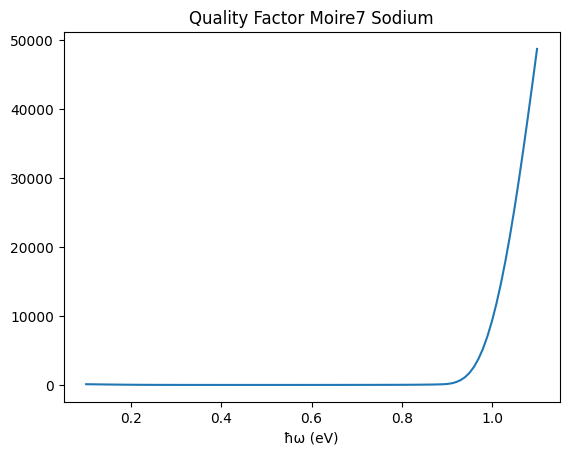

PyObject Text(0.5, 24.0, 'ħω (eV)')

In [143]:
plot(0.1:0.01:1.1, smooth(1 ./ loss[10:110]) * 1/ħ)
title("Quality Factor Moire7 Sodium")
xlabel("ħω (eV)")

In [113]:
τfirstorder

31-element Vector{Float64}:
 1.4370637516876605
 1.4339997675242175
 1.4310173429103827
 1.428113264094478
 1.4252844839809895
 1.4225281114659416
 1.4198414015808336
 1.4172217463745485
 1.41466666646956
 1.4121738032349511
 1.4097409115243231
 1.4073658529316013
 1.405046589522131
 ⋮
 1.3902214042628702
 1.38828544031437
 1.3863906080608843
 1.384535610448552
 1.3827192043915761
 1.3809401979942542
 1.379197447942802
 1.3774898570550798
 1.37581637197712
 1.3741759810162864
 1.3725677121017739
 1.37099063086372

In [104]:
subsampling = returnfermikpoint(Hwannier, cell_map, -2.217, Val(2), mesh=100, num_blocks=10, histogram_width=100)

(Real[0.3825248422879075 0.724947228118306 … 0.08291022319553765 0.649992963934932; 0.628646726798455 0.4257498653761336 … 0.32818254673210245 0.9508704819669311; 0.0 0.0 … 0.0 0.0], 0.01043)

In [111]:
τfirstorder = τ(Hwannier, cell_map, Pwannier, force_matrix, cellph_map, Heph, celleph_map, collect(0.8:0.01:1.1), -2.217, Val(2),
    supplydos=1.2, mesh=6, num_blocks=10, supplysampling=subsampling, histogram_width=100)

DOS at Fermi Energy is: 1.2
Sampling from 1043kpoints
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10


31-element Vector{Float64}:
 1.4370637516876605
 1.4339997675242175
 1.4310173429103827
 1.428113264094478
 1.4252844839809895
 1.4225281114659416
 1.4198414015808336
 1.4172217463745485
 1.41466666646956
 1.4121738032349511
 1.4097409115243231
 1.4073658529316013
 1.405046589522131
 ⋮
 1.3902214042628702
 1.38828544031437
 1.3863906080608843
 1.384535610448552
 1.3827192043915761
 1.3809401979942542
 1.379197447942802
 1.3774898570550798
 1.37581637197712
 1.3741759810162864
 1.3725677121017739
 1.37099063086372

In [83]:
E2up, Nup = find_chemical_potential(Eup, Dup)
E2dn, Ndn = find_chemical_potential(Edn, Ddn)

([-3.7561874306394953, -3.74619645465251, -3.7362054786655245, -3.726214502678539, -3.7162235266915533, -3.706232550704568, -3.6962415747175825, -3.686250598730597, -3.6762596227436113, -3.666268646756626  …  -0.9687051302705401, -0.9587141542835544, -0.9487231782965693, -0.9387322023095837, -0.928741226322598, -0.9187502503356124, -0.9087592743486272, -0.8987682983616416, -0.888777322374656, -0.8787863463876708], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.9990975986985504, 0.9990975986985504, 0.9990975986985504, 0.9990975986985504, 0.9990975986985504, 0.9990975986985504, 0.9990975986985504, 0.9990975986985504, 0.9990975986985504, 0.9990975986985504])

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87


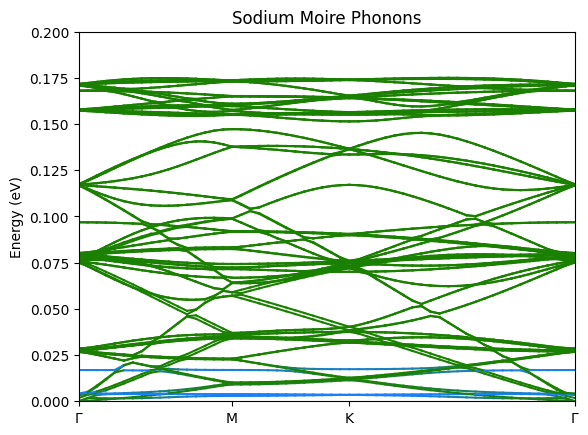

PyObject Text(0.5, 1.0, 'Sodium Moire Phonons')

In [16]:
for i in 1:87
    println(i)
    flush(stdout)
    for j in 1:55
        y1= phonon_bands[j, i]
        y2 = phonon_bands[j+1, i]
        kpt = kpts[j]
        Na_Overlap = sum((abs.(phonon_dispersionmodes(force_matrix, phonon_cell_map, kpt)[2][85:87, i])).^2)
        plot([j-1, j], [y1, y2], color=[0.1, 0.5, Na_Overlap]) #linewidth=(3+Na_Overlap*4),)
    end
end
label_plots()
ylim(0, 0.2)
ylabel("Energy (eV)")
xlim(0, 55)
title("Sodium Moire Phonons")

In [40]:
eph_lifetimes = [JJDFTX.migdal_approximation(Hwannierup, cellmapup, HePhWannier, cellMapEph, force_matrix, phonon_cell_map, 
lattice_vectors, unnormalize_kvector(lattice_vectors, [1, 0, 0]*i/60), -2.6,  mesh=10, histogram_width=10) for i in 1:60] 

60-element Vector{Float64}:
 0.032680431595611396
 0.038823940359654543
 0.040077694331482894
 0.03408737035392326
 0.036896769296543425
 0.02561724611008775
 0.038389060055441855
 0.022173929619297945
 0.008947698226173879
 0.0045568043632789315
 0.007263726100677648
 0.007201317127085491
 0.003055079385091026
 ⋮
 0.007263726100677679
 0.004556804363279002
 0.008947698226174118
 0.022173929619298146
 0.038389060055442376
 0.02561724611008852
 0.036896769296543515
 0.034087370353923785
 0.04007769433148359
 0.03882394035965525
 0.03268043159561168
 0.02604515283444016

In [65]:
#phonon lifetimes
lifetimes = zeros(56, 87)
for (i, kpt) in enumerate(kpts[2:10]) 
    println(i)
    lifetimes[i, :] = forderphononloss(Hwannierup, cellmapup, HePhWannier, cellMapEph, force_matrix, phonon_cell_map,kpt, -2.4, mesh=30, histogram_width=10)
end

1
2
3
4
5
6
7
8
9


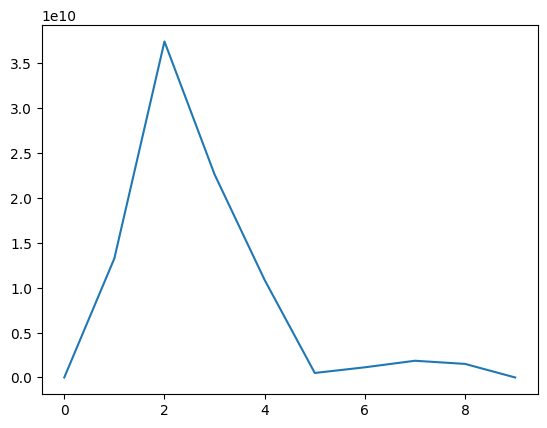

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f3844474fd0>

In [74]:
plot(lifetimes[1:10, 80])

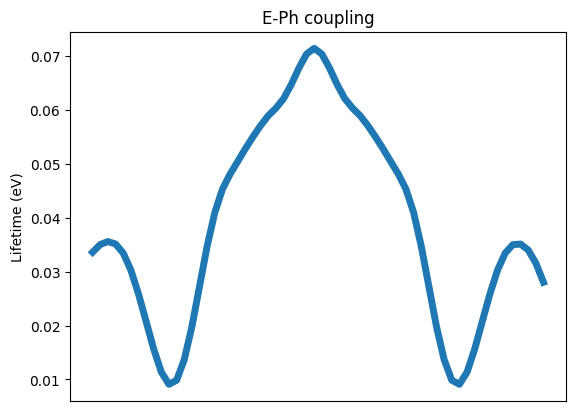

PyObject Text(24.000000000000007, 0.5, 'Lifetime (eV)')

In [42]:
plot(smooth(eph_lifetimes, win_len=10), linewidth=5)
xticks(Float64[])
title("E-Ph coupling")
ylabel("Lifetime (eV)")

In [59]:
sorderloss = second_order_damping(Hwannierup, cellmapup, HePhWannier, cellMapEph, force_matrix, phonon_cell_map, 
    lattice_vectors, q, -2.4; histogram_width=3, mesh=7, energy_range=3) 


1
1
1
1
1
1
1


90-element Vector{Float64}:
 0.0
 0.0
 0.0
 2.8547095164137954e12
 1.895620918498698e13
 1.1078739390236305e13
 2.5473004505564988e14
 4.234878398207272e14
 9.149427956187969e14
 2.8785150952562365e15
 1.4573946911460098e15
 1.5830594743704804e16
 8.477213036102494e16
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

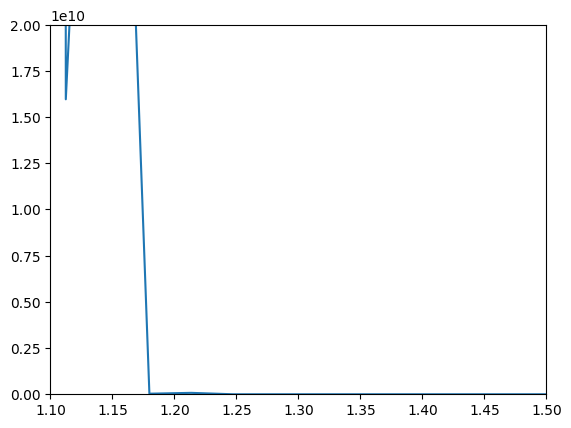

(0.0, 2.0e10)

In [58]:
plot(range(0, 3, length=90), sorderloss)
xlim(1.1, 1.5)
ylim(0, 0.2e11)

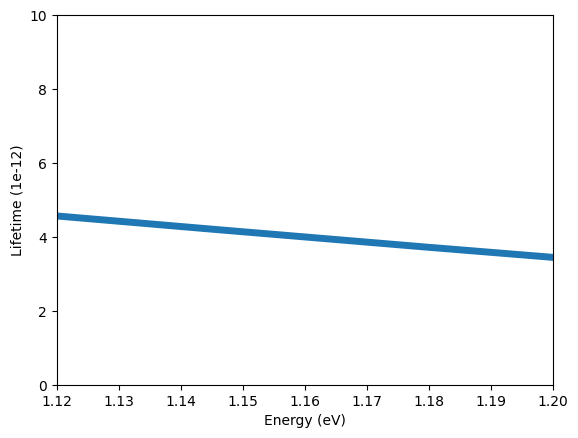

PyObject Text(0.5, 24.0, 'Energy (eV)')

In [93]:
plot(range(0, 3, length=90)[34:end], 1e12/smooth(sorderloss[34:end]), linewidth=5)
xlim(1.12, 1.2)
ylabel("Lifetime (1e-12)")
ylim(0, 10)
xlabel("Energy (eV)")

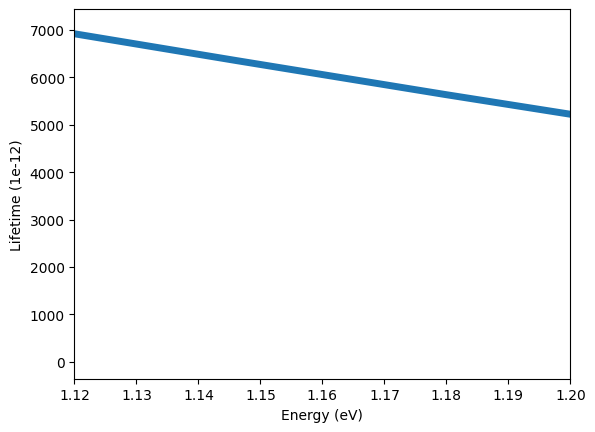

PyObject Text(0.5, 24.0, 'Energy (eV)')

In [103]:
plot(range(0, 3, length=90)[34:end], 1/smooth(sorderloss[34:end])/ħ, linewidth=5)
xlim(1.12, 1.2)
ylabel("Lifetime (1e-12)")
#ylim(0, 1000)
xlabel("Energy (eV)")

In [102]:
smooth(sorderloss[34:end])

57-element Vector{Float64}:
 5.255956216910789e10
 4.7147724309958595e10
 4.183408696068279e10
 3.66814282128136e10
 3.1748562330460213e10
 2.7088891547932102e10
 2.2749091129498474e10
 1.8767960069475677e10
 1.5175465732220604e10
 1.1992005956164314e10
 9.227906791333225e9
 6.883168237727339e9
 4.947464245320241e9
 ⋮
 0.0
 2.170138888888889e-5
 0.0
 2.170138888888889e-5
 1.0850694444444445e-5
 1.0850694444444445e-5
 1.6276041666666666e-5
 2.170138888888889e-5
 5.4253472222222224e-6
 1.6276041666666666e-5
 5.4253472222222224e-6
 1.0850694444444445e-5

In [43]:
pwd()

"/home/gridsan/aligho/Plasmons/Plasmons_Paper/Moire_Figs/Moire7_with_Alkali/Sodium/optimize_from_3angstroms/interpolation_correction"

In [6]:
readdir()

63-element Vector{String}:
 ".ipynb_checkpoints"
 "Analyze.ipynb"
 "Moire.bands.in"
 "Moire.in"
 "Moire.out"
 "Moire7-0.666-0.333.ionpos"
 "Moire7.lattice"
 "Na.eigenvals"
 "Na.ionpos"
 "Na.lattice"
 "Na.phononBasis"
 "Na.phononCellMap"
 "Na.phononCellWeights"
 ⋮
 "wannier.mlwfHePhSumDn"
 "wannier.mlwfHePhSumUp"
 "wannier.mlwfHePhUp"
 "wannier.mlwfM0Dn"
 "wannier.mlwfM0Up"
 "wannier.mlwfUDn"
 "wannier.mlwfUUp"
 "wannier.out"
 "wannierDn.map.txt"
 "wannierDn.txt"
 "wannierUp.map.txt"
 "wannierUp.txt"